In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import download_prices

from src.returns import (
    calculate_simple_returns,
    calculate_log_returns,
    validate_returns
)

from src.portfolio import (
    calculate_portfolio_returns,
    calculate_portfolio_pnl
)

from src.risk_metrics import (
    calculate_portfolio_statistics
)

from src.historical_simulation_var import (
    historical_var
)

from src.historical_simulation_es import (
    historical_expected_shortfall
)

from src.variance_covariance_var import (
    calculate_portfolio_mean_return,
    calculate_portfolio_volatility,
    calculate_variance_covariance_var
)

from src.variance_covariance_es import (
    calculate_variance_covariance_es
)

from src.monte_carlo_var import (
    simulate_portfolio_returns,
    calculate_monte_carlo_var
)

from src.monte_carlo_es import (
    calculate_monte_carlo_es
)

from src.rolling_var import (
    calculate_rolling_historical_var_es,
    calculate_rolling_variance_covariance_var_es,
    calculate_rolling_monte_carlo_var_es
)

In [3]:
tickers = [
    "RELIANCE.NS",
    "ESCORTS.NS",
    "INFY.NS",
    "ABB.NS",
    "HDFCBANK.NS"
]

#weightage of stocks in portfolio
weights = [
    0.20,   # RELIANCE
    0.20,   # ESCORTS
    0.20,   # INFY
    0.20,   # ABB
    0.20    # HDFCBANK
]

#assigning portfolio value in Rs
portfolio_value = 10_000_000

In [4]:
prices = download_prices(
    tickers,
    "2022-04-01",
    "2026-03-31"
)

prices = prices.round(2)

print(prices.head())

[*********************100%***********************]  5 of 5 completed

Ticker       ABB.NS  ESCORTS.NS  HDFCBANK.NS  INFY.NS  RELIANCE.NS
Date                                                              
2022-04-01  2043.44     1635.69       704.66  1672.63      1202.88
2022-04-04  2059.15     1700.33       775.21  1654.53      1206.44
2022-04-05  2133.57     1795.94       752.50  1635.33      1189.39
2022-04-06  2135.41     1820.12       725.64  1606.99      1186.21
2022-04-07  2118.69     1652.36       709.69  1591.31      1165.29


In [5]:
returns = calculate_simple_returns(prices)

print(returns.head())

Ticker        ABB.NS  ESCORTS.NS  HDFCBANK.NS   INFY.NS  RELIANCE.NS
Date                                                                
2022-04-04  0.007688    0.039518     0.100119 -0.010821     0.002960
2022-04-05  0.036141    0.056230    -0.029295 -0.011605    -0.014132
2022-04-06  0.000862    0.013464    -0.035694 -0.017330    -0.002674
2022-04-07 -0.007830   -0.092170    -0.021981 -0.009757    -0.017636
2022-04-08  0.021348   -0.061246    -0.001395  0.001986     0.016631


In [6]:
print(validate_returns(returns))

{'rows': 986, 'columns': 5, 'missing_values': np.int64(0), 'infinite_values': np.int64(0)}


In [7]:
portfolio_returns = calculate_portfolio_returns(
    returns,
    weights
)

print(prices.head().round(2))

Ticker       ABB.NS  ESCORTS.NS  HDFCBANK.NS  INFY.NS  RELIANCE.NS
Date                                                              
2022-04-01  2043.44     1635.69       704.66  1672.63      1202.88
2022-04-04  2059.15     1700.33       775.21  1654.53      1206.44
2022-04-05  2133.57     1795.94       752.50  1635.33      1189.39
2022-04-06  2135.41     1820.12       725.64  1606.99      1186.21
2022-04-07  2118.69     1652.36       709.69  1591.31      1165.29


In [8]:
#calculating daily PnL
portfolio_pnl = calculate_portfolio_pnl(
    portfolio_returns,
    portfolio_value
)

print(portfolio_pnl.head(10))

Date
2022-04-04    278927.991277
2022-04-05     74678.213350
2022-04-06    -82743.442739
2022-04-07   -298747.188883
2022-04-08    -45351.545925
2022-04-11   -110984.815443
2022-04-12   -156029.769147
2022-04-13    -16178.120083
2022-04-18   -279785.225393
2022-04-19   -104897.900524
Name: Portfolio P&L, dtype: float64


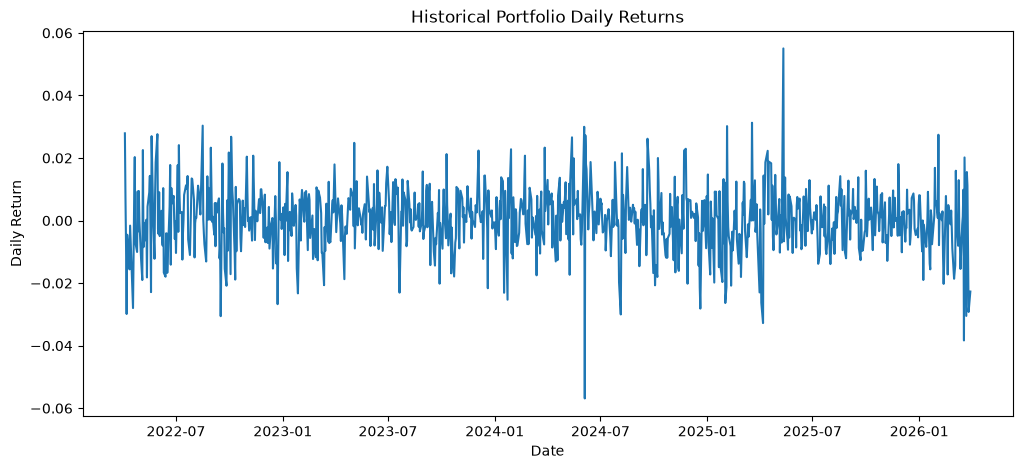

In [33]:
#Plotting Portfolio returns
plt.figure(figsize=(12, 5))

plt.plot(
    portfolio_returns.index,
    portfolio_returns
)

plt.title("Historical Portfolio Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.show()

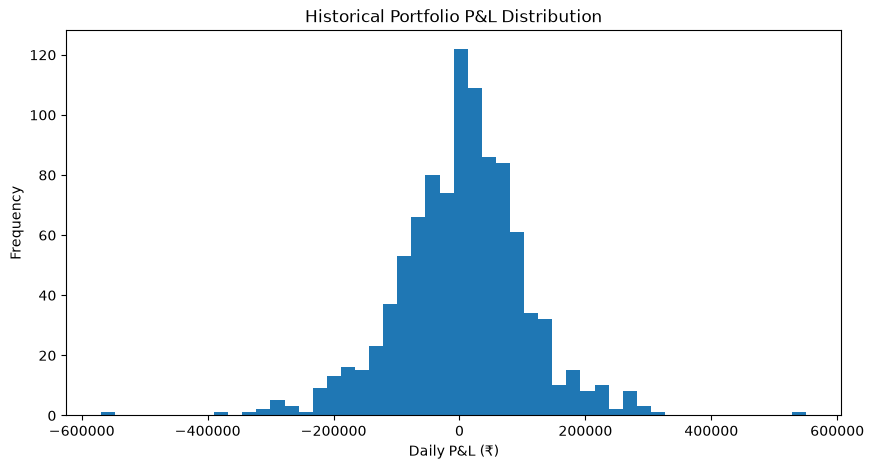

In [10]:
#Plotting PnL Distribution
plt.figure(figsize=(10, 5))

plt.hist(
    portfolio_pnl,
    bins=50
)

plt.title("Historical Portfolio P&L Distribution")
plt.xlabel("Daily P&L (₹)")
plt.ylabel("Frequency")

plt.show()

In [11]:
#portfolio statistics

statistics = calculate_portfolio_statistics(
    portfolio_returns
)

for key, value in statistics.items():
    print(f"{key}: {value:.6f}")

mean_return: 0.000418
volatility: 0.010154
minimum_return: -0.056875
maximum_return: 0.055030
skewness: -0.160660
kurtosis: 2.364926


In [12]:
#Calculate Historical VaR
# 1-day 95% VaR 
var_95 = historical_var(
    portfolio_returns,
    portfolio_value,
    confidence_level=0.95
)

# 1-day 99% VaR 
var_99 = historical_var(
    portfolio_returns,
    portfolio_value,
    confidence_level=0.99
)

print(f"95% 1-Day VaR: ₹{var_95:,.2f}")
print(f"99% 1-Day VaR: ₹{var_99:,.2f}")

95% 1-Day VaR: ₹167,646.97
99% 1-Day VaR: ₹269,176.24


In [13]:
# Expected Shortfall at 95% CI
es_95 = historical_expected_shortfall(
    portfolio_returns,
    portfolio_value,
    confidence_level=0.95
)

# Expected Shortfall at 99% CI
es_99 = historical_expected_shortfall(
    portfolio_returns,
    portfolio_value,
    confidence_level=0.99
)

print(f"95% Expected Shortfall: ₹{es_95:,.2f}")
print(f"99% Expected Shortfall: ₹{es_99:,.2f}")

95% Expected Shortfall: ₹229,691.69
99% Expected Shortfall: ₹334,273.11


In [14]:
# Variance-Covariance VaR

# portfolio mean return
portfolio_mean_vc = calculate_portfolio_mean_return(
    returns,
    np.array(weights)
)

print(
    f"Portfolio Mean Daily Return: "
    f"{portfolio_mean_vc * 100:.4f}%"
)

# calculate portfolio volatility
portfolio_volatility_vc = calculate_portfolio_volatility(
    returns,
    np.array(weights)
)

print(
    f"Portfolio Daily Volatility: "
    f"{portfolio_volatility_vc * 100:.4f}%"
)

# calculate 95% VaR vc
var_vc_95 = calculate_variance_covariance_var(
    returns,
    np.array(weights),
    portfolio_value,
    confidence_level=0.95
)

print(
    f"Variance-Covariance 95% VaR: "
    f"₹{var_vc_95:,.2f}"
)

# calculate 99% VaR vc
var_vc_99 = calculate_variance_covariance_var(
    returns,
    np.array(weights),
    portfolio_value,
    confidence_level=0.99
)

print(
    f"Variance-Covariance 99% VaR: "
    f"₹{var_vc_99:,.2f}"
)

Portfolio Mean Daily Return: 0.0418%
Portfolio Daily Volatility: 1.0154%
Variance-Covariance 95% VaR: ₹162,844.55
Variance-Covariance 99% VaR: ₹232,044.74


In [15]:
#calculate 95% ES vc
es_vc_95 = calculate_variance_covariance_es(
    returns,
    np.array(weights),
    portfolio_value,
    confidence_level=0.95
)

print(
    f"Variance-Covariance 95% ES: "
    f"₹{es_vc_95:,.2f}"
)

#calculate 99% ES vc
es_vc_99 = calculate_variance_covariance_es(
    returns,
    np.array(weights),
    portfolio_value,
    confidence_level=0.99
)

print(
    f"Variance-Covariance 99% ES: "
    f"₹{es_vc_99:,.2f}"
)

Variance-Covariance 95% ES: ₹205,274.74
Variance-Covariance 99% ES: ₹266,453.85


In [16]:
# stats of monte carlo VaR
simulated_portfolio_returns = simulate_portfolio_returns(
    returns=returns,
    weights=np.array(weights),
    n_simulations=10000,
    random_seed=42
)

print("Number of simulated scenarios:", len(simulated_portfolio_returns))
print("Mean simulated portfolio return:", simulated_portfolio_returns.mean())
print("Minimum simulated portfolio return:", simulated_portfolio_returns.min())
print("Maximum simulated portfolio return:", simulated_portfolio_returns.max())

# 95% VaR mc
var_mc_95 = calculate_monte_carlo_var(
    returns=returns,
    weights=np.array(weights),
    portfolio_value=portfolio_value,
    confidence_level=0.95,
    n_simulations=10000,
    random_seed=42
)

print(
    f"Monte Carlo 95% VaR: ₹{var_mc_95:,.2f}"
)

# 99% VaR mc
var_mc_99 = calculate_monte_carlo_var(
    returns=returns,
    weights=np.array(weights),
    portfolio_value=portfolio_value,
    confidence_level=0.99,
    n_simulations=10000,
    random_seed=42
)

print(
    f"Monte Carlo 99% VaR: ₹{var_mc_99:,.2f}"
)

Number of simulated scenarios: 10000
Mean simulated portfolio return: 0.00042305064120087474
Minimum simulated portfolio return: -0.04242384233750541
Maximum simulated portfolio return: 0.04332989606152848
Monte Carlo 95% VaR: ₹164,117.01
Monte Carlo 99% VaR: ₹236,212.57


In [17]:
# expected shortfall for monte carlo 95% & 99%

# mc es 95%
es_mc_95 = calculate_monte_carlo_es(
    returns=returns,
    weights=np.array(weights),
    portfolio_value=portfolio_value,
    confidence_level=0.95,
    n_simulations=10000,
    random_seed=42
)

print(
    f"Monte Carlo 95% ES: ₹{es_mc_95:,.2f}"
)

# mc es 99%
es_mc_99 = calculate_monte_carlo_es(
    returns=returns,
    weights=np.array(weights),
    portfolio_value=portfolio_value,
    confidence_level=0.99,
    n_simulations=10000,
    random_seed=42
)

print(
    f"Monte Carlo 99% ES: ₹{es_mc_99:,.2f}"
)

Monte Carlo 95% ES: ₹207,001.91
Monte Carlo 99% ES: ₹271,029.61


In [18]:
model_comparison = pd.DataFrame({
    "Model": [
        "Historical Simulation",
        "Variance-Covariance",
        "Monte Carlo"
    ],
    "95% VaR": [
        var_95,
        var_vc_95,
        var_mc_95
    ],
    "99% VaR": [
        var_99,
        var_vc_99,
        var_mc_99
    ],
    "95% ES": [
        es_95,
        es_vc_95,
        es_mc_95
    ],
    "99% ES": [
        es_99,
        es_vc_99,
        es_mc_99
    ]
})

print(model_comparison)

                   Model        95% VaR        99% VaR         95% ES  \
0  Historical Simulation  167646.966941  269176.235470  229691.685457   
1    Variance-Covariance  162844.546629  232044.736375  205274.742783   
2            Monte Carlo  164117.012863  236212.573777  207001.912772   

          99% ES  
0  334273.108595  
1  266453.853639  
2  271029.609636  


In [19]:
# Historical Simulation Rolling VaR and Expected Shortfall
rolling_historical_95 = calculate_rolling_historical_var_es(
    portfolio_returns=portfolio_returns,
    portfolio_value=portfolio_value,
    window=250,
    confidence_level=0.95
)

print(rolling_historical_95.head())

rolling_historical_99 = calculate_rolling_historical_var_es(
    portfolio_returns=portfolio_returns,
    portfolio_value=portfolio_value,
    window=250,
    confidence_level=0.99
)

print(rolling_historical_99.head())

                      VaR             ES
2023-04-05  169438.199330  226124.636983
2023-04-06  169438.199330  226124.636983
2023-04-10  169438.199330  226124.636983
2023-04-11  169438.199330  226124.636983
2023-04-12  166766.671168  215995.509155
                      VaR             ES
2023-04-05  273669.454732  294730.103114
2023-04-06  273669.454732  294730.103114
2023-04-10  273669.454732  294730.103114
2023-04-11  273669.454732  294730.103114
2023-04-12  250395.242624  284249.060412


In [20]:
print(
    "95% rolling observations:",
    len(rolling_historical_95)
)

print(
    "99% rolling observations:",
    len(rolling_historical_99)
)

print(
    "Latest Rolling Historical 95% VaR:",
    f"₹{rolling_historical_95['VaR'].iloc[-1]:,.2f}"
)

print(
    "Latest Rolling Historical 95% ES:",
    f"₹{rolling_historical_95['ES'].iloc[-1]:,.2f}"
)

print(
    "Latest Rolling Historical 99% VaR:",
    f"₹{rolling_historical_99['VaR'].iloc[-1]:,.2f}"
)

print(
    "Latest Rolling Historical 99% ES:",
    f"₹{rolling_historical_99['ES'].iloc[-1]:,.2f}"
)

95% rolling observations: 737
99% rolling observations: 737
Latest Rolling Historical 95% VaR: ₹149,449.13
Latest Rolling Historical 95% ES: ₹237,621.24
Latest Rolling Historical 99% VaR: ₹298,677.85
Latest Rolling Historical 99% ES: ₹338,631.79


In [21]:
# Variance Covarinace Rolling VaR and Expected Shortfall
rolling_vc_95 = calculate_rolling_variance_covariance_var_es(
    returns=returns,
    weights=weights,
    portfolio_value=portfolio_value,
    window=250,
    confidence_level=0.95
)

print(rolling_vc_95.head())

rolling_vc_99 = calculate_rolling_variance_covariance_var_es(
    returns=returns,
    weights=weights,
    portfolio_value=portfolio_value,
    window=250,
    confidence_level=0.99
)

print(rolling_vc_99.head())

                      VaR             ES
2023-04-05  172869.327770  217654.465131
2023-04-06  171490.321324  215714.671854
2023-04-10  171671.433874  215856.056836
2023-04-11  171519.572942  215683.218731
2023-04-12  167324.383986  210776.569696
                      VaR             ES
2023-04-05  245969.741767  282613.532961
2023-04-06  243675.392600  279860.340599
2023-04-10  243791.659939  279944.102317
2023-04-11  243605.559076  279740.837654
2023-04-12  238249.091415  273802.243954


In [22]:
print(
    "95% rolling VC observations:",
    len(rolling_vc_95)
)

print(
    "99% rolling VC observations:",
    len(rolling_vc_99)
)

print(
    "Latest Rolling VC 95% VaR:",
    f"₹{rolling_vc_95['VaR'].iloc[-1]:,.2f}"
)

print(
    "Latest Rolling VC 95% ES:",
    f"₹{rolling_vc_95['ES'].iloc[-1]:,.2f}"
)

print(
    "Latest Rolling VC 99% VaR:",
    f"₹{rolling_vc_99['VaR'].iloc[-1]:,.2f}"
)

print(
    "Latest Rolling VC 99% ES:",
    f"₹{rolling_vc_99['ES'].iloc[-1]:,.2f}"
)

95% rolling VC observations: 737
99% rolling VC observations: 737
Latest Rolling VC 95% VaR: ₹167,658.27
Latest Rolling VC 95% ES: ₹209,600.79
Latest Rolling VC 99% VaR: ₹236,118.82
Latest Rolling VC 99% ES: ₹270,436.74


In [ ]:
# Monte Carlo Rolling VaR and Expected Shortfall
rolling_mc_95 = calculate_rolling_monte_carlo_var_es(
    returns=returns,
    weights=weights,
    portfolio_value=portfolio_value,
    window=250,
    confidence_level=0.95,
    n_simulations=10000,
    random_seed=42
)

print(rolling_mc_95.head())

rolling_mc_99 = calculate_rolling_monte_carlo_var_es(
    returns=returns,
    weights=weights,
    portfolio_value=portfolio_value,
    window=250,
    confidence_level=0.99,
    n_simulations=10000,
    random_seed=42
)

print(rolling_mc_99.head())

                      VaR             ES
2023-04-05  172480.097388  219126.284950
2023-04-06  175963.325830  221920.321807
2023-04-10  168710.145125  214762.950606
2023-04-11  174613.490683  218825.246806
2023-04-12  170686.366291  215211.429479
                      VaR             ES
2023-04-05  250430.614841  288257.386734
2023-04-06  253051.438025  290398.349353
2023-04-10  243352.944151  276823.267145
2023-04-11  247374.781331  283539.836128
2023-04-12  239949.579744  278888.029583


In [28]:
print(
    "95% rolling MC observations:",
    len(rolling_mc_95)
)

print(
    "99% rolling MC observations:",
    len(rolling_mc_99)
)

print(
    "Latest Rolling MC 95% VaR:",
    f"₹{rolling_mc_95['VaR'].iloc[-1]:,.2f}"
)

print(
    "Latest Rolling MC 95% ES:",
    f"₹{rolling_mc_95['ES'].iloc[-1]:,.2f}"
)

print(
    "Latest Rolling MC 99% VaR:",
    f"₹{rolling_mc_99['VaR'].iloc[-1]:,.2f}"
)

print(
    "Latest Rolling MC 99% ES:",
    f"₹{rolling_mc_99['ES'].iloc[-1]:,.2f}"
)

95% rolling MC observations: 737
99% rolling MC observations: 737
Latest Rolling MC 95% VaR: ₹166,787.67
Latest Rolling MC 95% ES: ₹210,474.04
Latest Rolling MC 99% VaR: ₹239,972.17
Latest Rolling MC 99% ES: ₹276,602.91


## Rolling VaR & Expected Shortfall

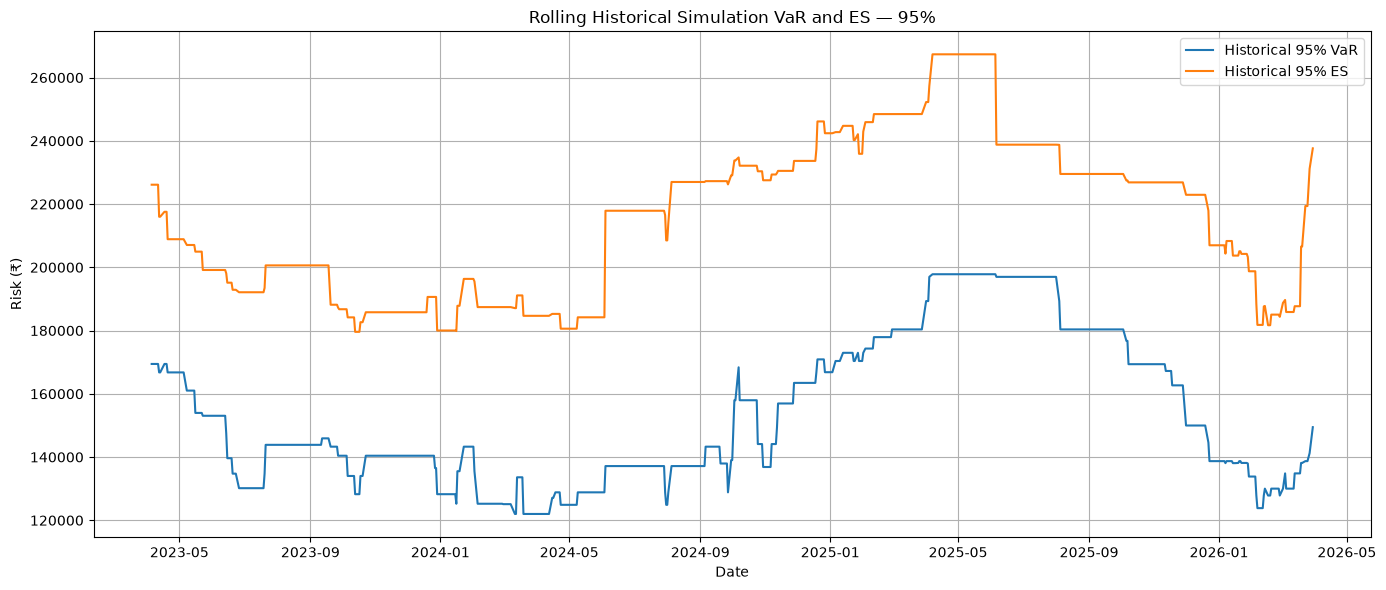

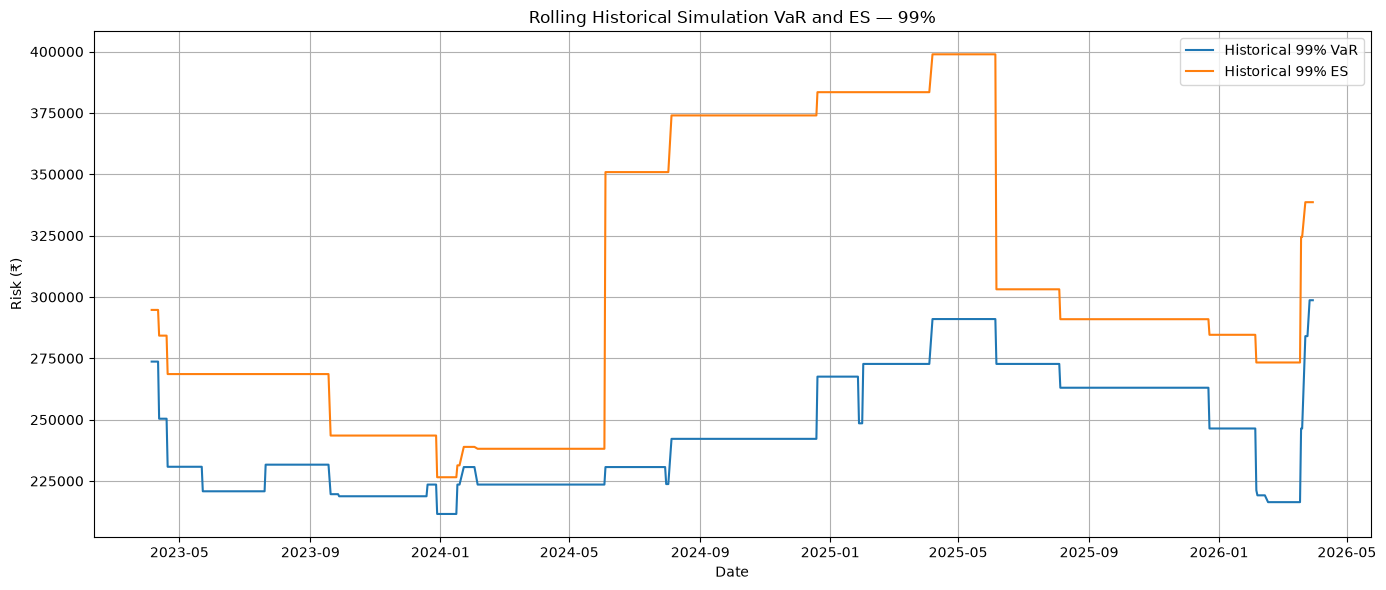

In [44]:
# Historical Simulation 95% VaR & ES
plt.figure(figsize=(14, 6))

plt.plot(
    rolling_historical_95.index,
    rolling_historical_95["VaR"],
    label="Historical 95% VaR"
)

plt.plot(
    rolling_historical_95.index,
    rolling_historical_95["ES"],
    label="Historical 95% ES"
)

plt.title("Rolling Historical Simulation VaR and ES — 95%")
plt.xlabel("Date")
plt.ylabel("Risk (₹)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

# Historical Simulation 99% VaR & ES
plt.figure(figsize=(14, 6))

plt.plot(
    rolling_historical_99.index,
    rolling_historical_99["VaR"],
    label="Historical 99% VaR"
)

plt.plot(
    rolling_historical_99.index,
    rolling_historical_99["ES"],
    label="Historical 99% ES"
)

plt.title("Rolling Historical Simulation VaR and ES — 99%")
plt.xlabel("Date")
plt.ylabel("Risk (₹)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

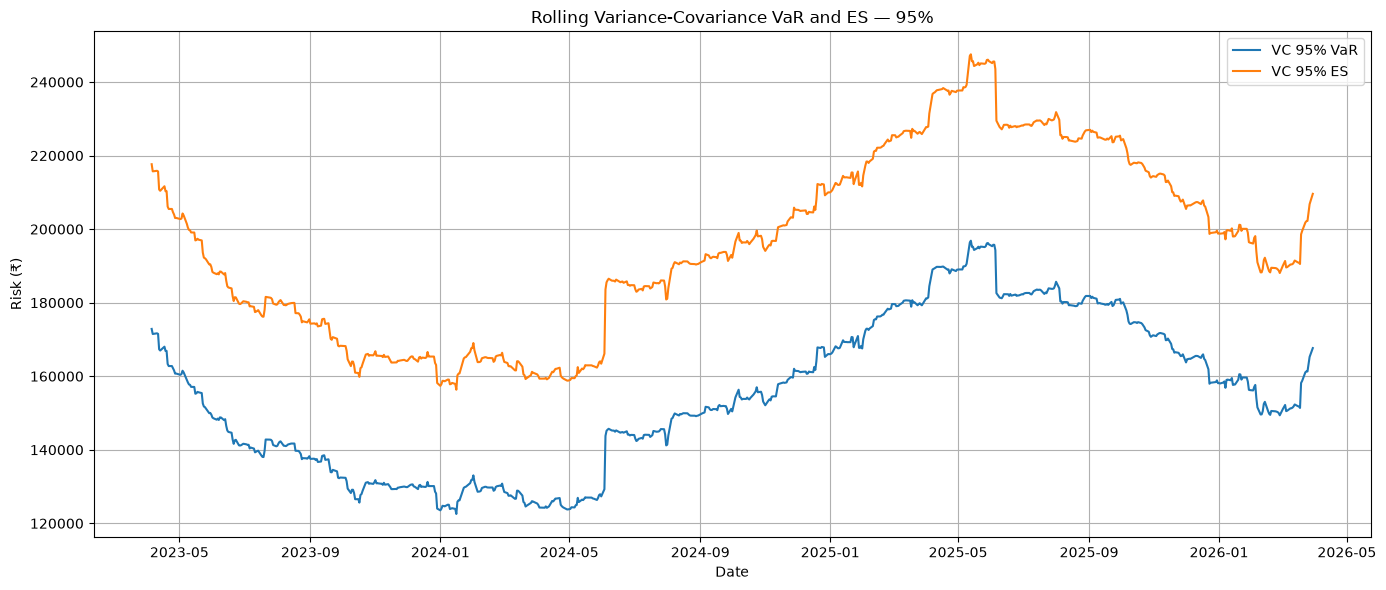

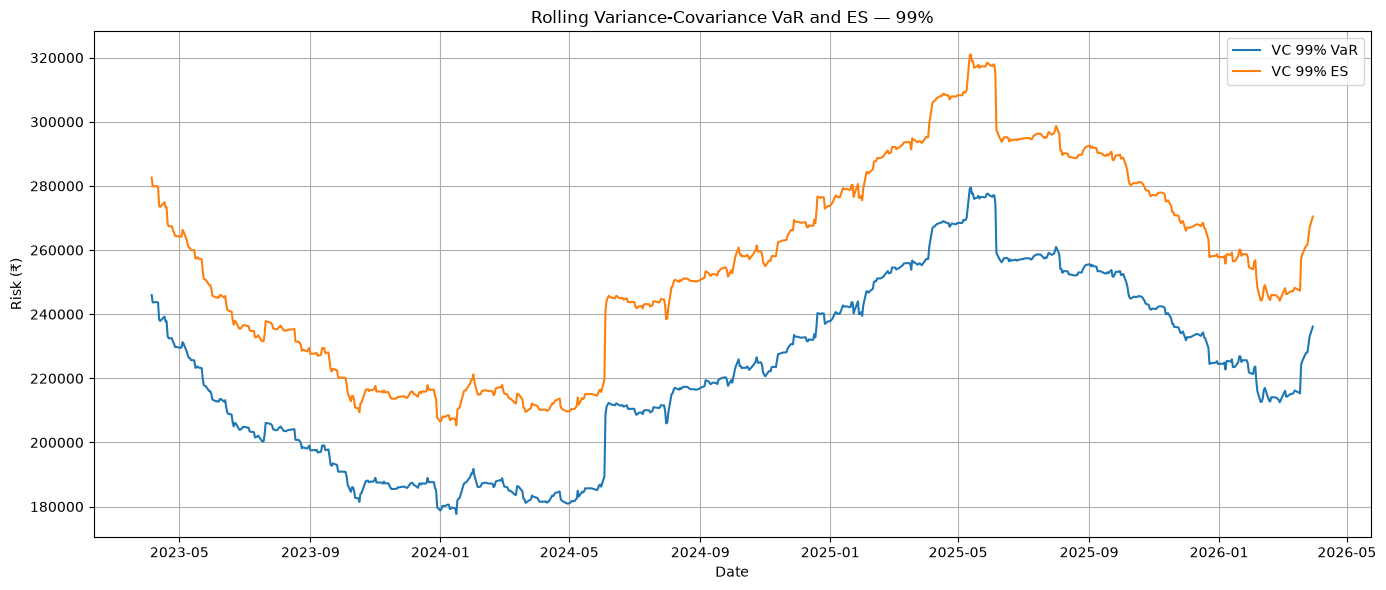

In [42]:
# Variance Covariance 95% VaR & ES
plt.figure(figsize=(14, 6))

plt.plot(
    rolling_vc_95.index,
    rolling_vc_95["VaR"],
    label="VC 95% VaR"
)

plt.plot(
    rolling_vc_95.index,
    rolling_vc_95["ES"],
    label="VC 95% ES"
)

plt.title("Rolling Variance-Covariance VaR and ES — 95%")
plt.xlabel("Date")
plt.ylabel("Risk (₹)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

# Variance Covariance 99% VaR & ES
plt.figure(figsize=(14, 6))

plt.plot(
    rolling_vc_99.index,
    rolling_vc_99["VaR"],
    label="VC 99% VaR"
)

plt.plot(
    rolling_vc_99.index,
    rolling_vc_99["ES"],
    label="VC 99% ES"
)

plt.title("Rolling Variance-Covariance VaR and ES — 99%")
plt.xlabel("Date")
plt.ylabel("Risk (₹)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

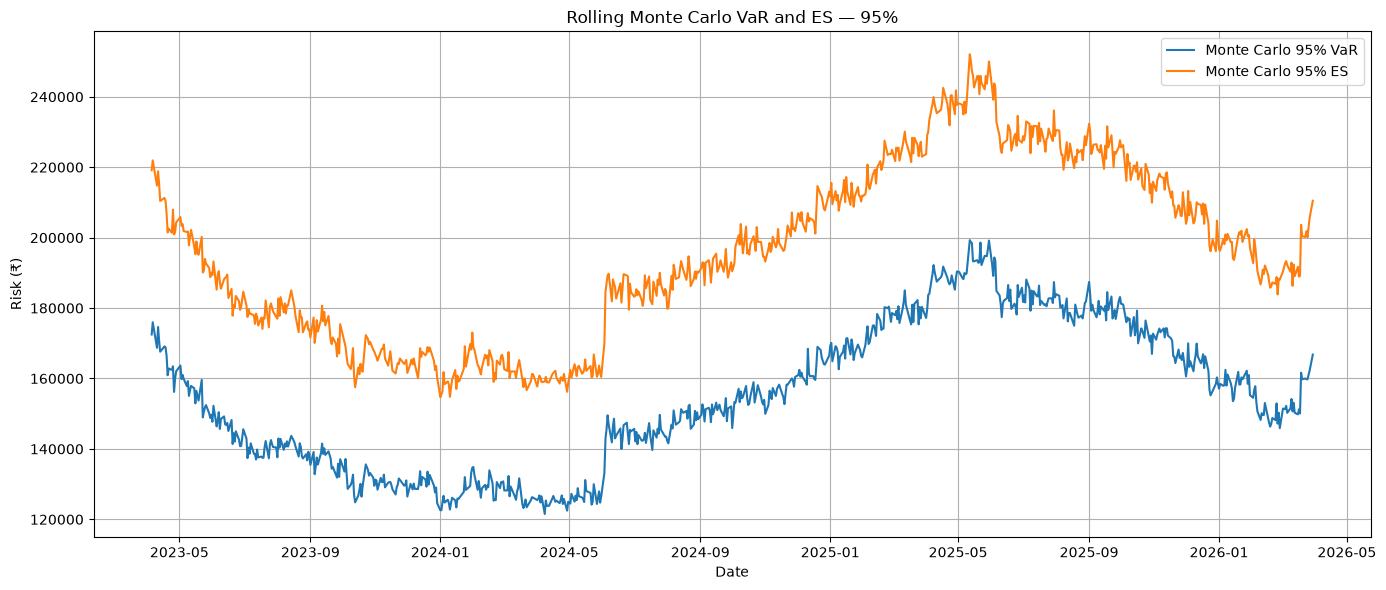

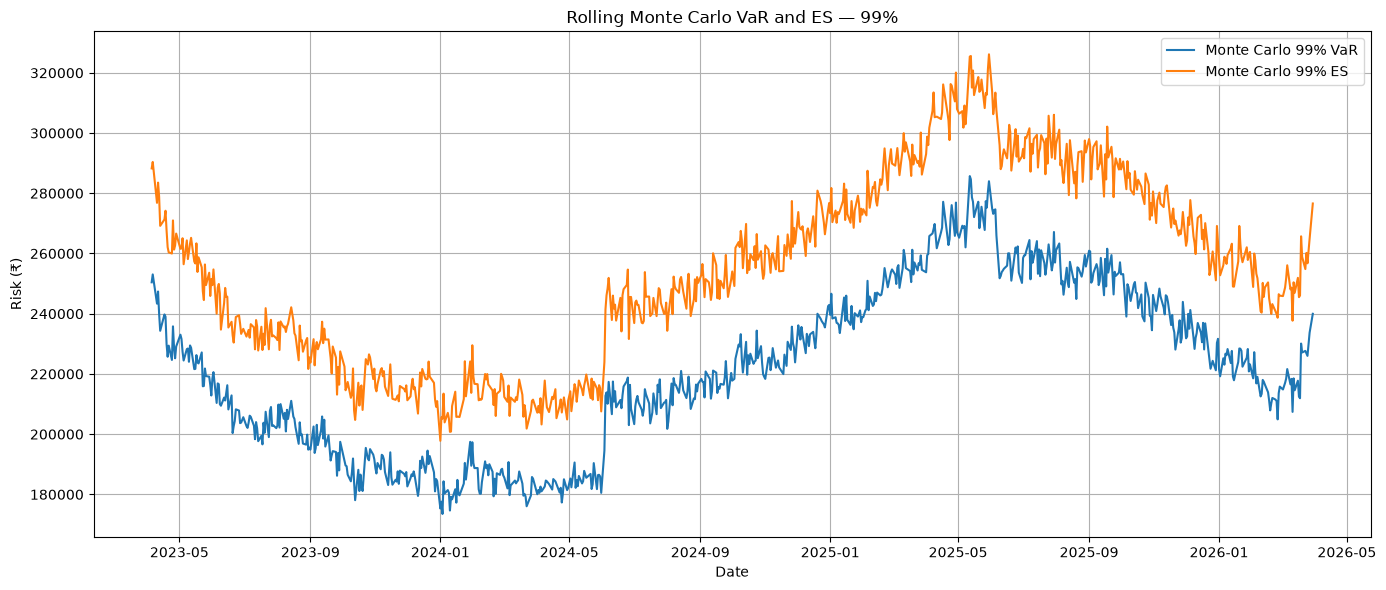

In [43]:
# Monte Carlo 95% VaR & ES
plt.figure(figsize=(14, 6))

plt.plot(
    rolling_mc_95.index,
    rolling_mc_95["VaR"],
    label="Monte Carlo 95% VaR"
)

plt.plot(
    rolling_mc_95.index,
    rolling_mc_95["ES"],
    label="Monte Carlo 95% ES"
)

plt.title("Rolling Monte Carlo VaR and ES — 95%")
plt.xlabel("Date")
plt.ylabel("Risk (₹)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

# Monte Carlo 99% VaR & ES
plt.figure(figsize=(14, 6))

plt.plot(
    rolling_mc_99.index,
    rolling_mc_99["VaR"],
    label="Monte Carlo 99% VaR"
)

plt.plot(
    rolling_mc_99.index,
    rolling_mc_99["ES"],
    label="Monte Carlo 99% ES"
)

plt.title("Rolling Monte Carlo VaR and ES — 99%")
plt.xlabel("Date")
plt.ylabel("Risk (₹)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

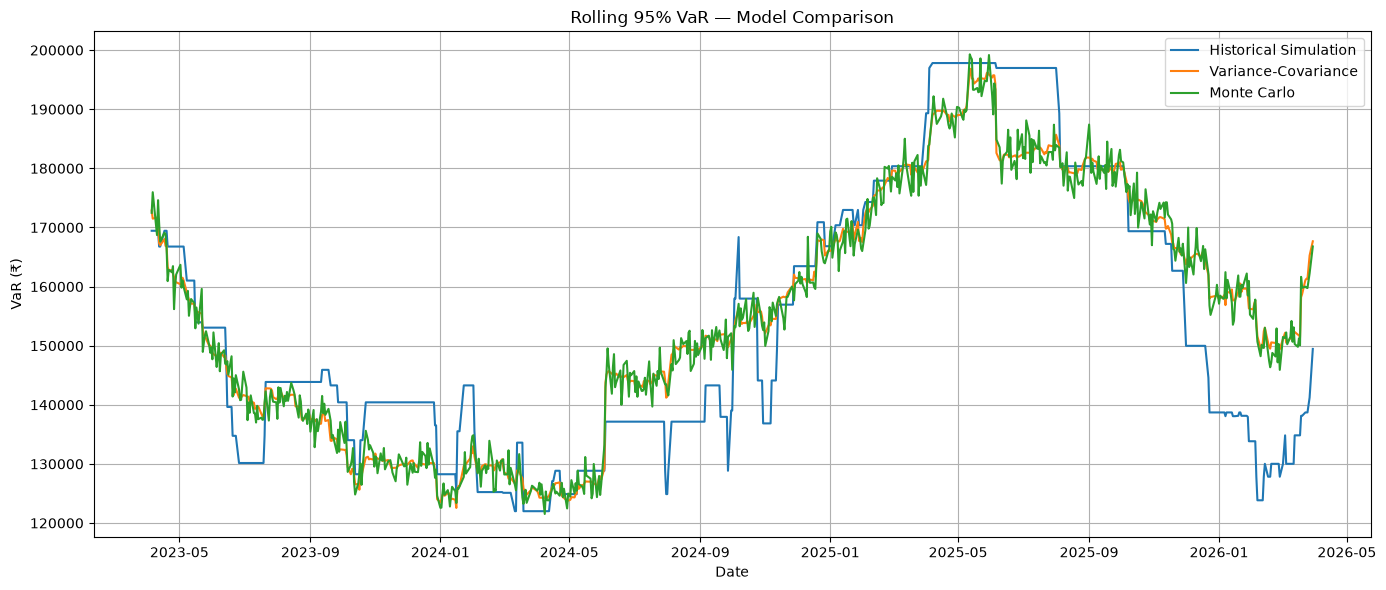

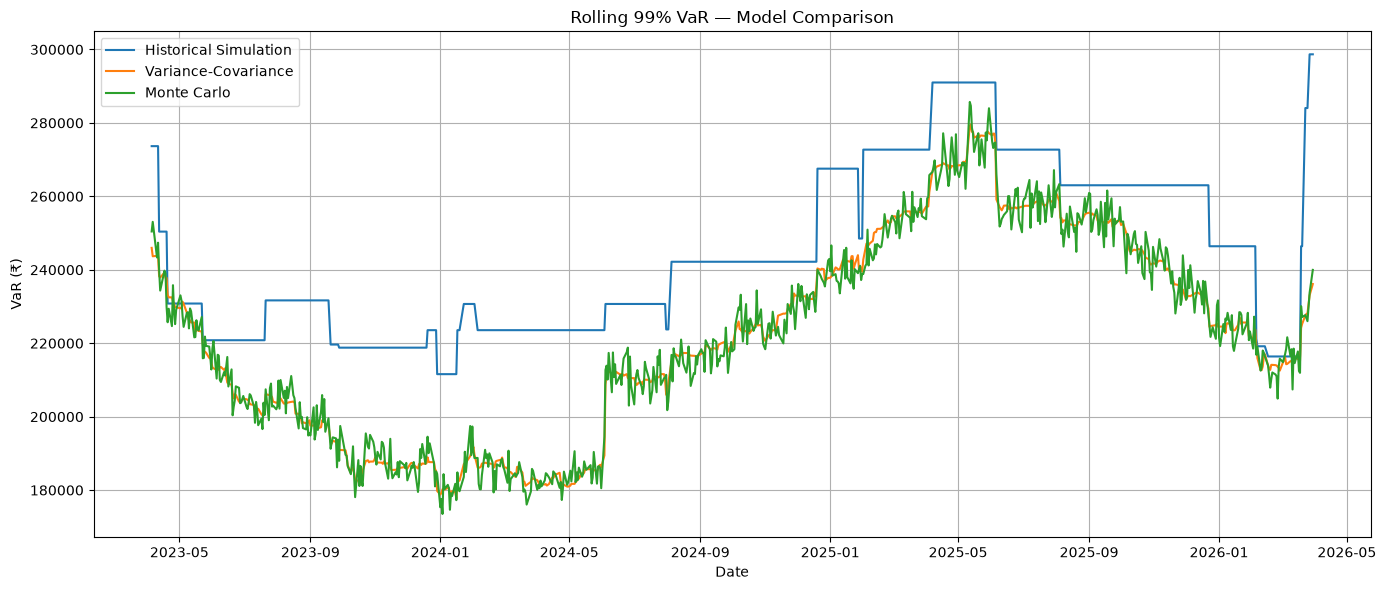

In [46]:
#95% VaR — all three models
plt.figure(figsize=(14, 6))

plt.plot(
    rolling_historical_95.index,
    rolling_historical_95["VaR"],
    label="Historical Simulation"
)

plt.plot(
    rolling_vc_95.index,
    rolling_vc_95["VaR"],
    label="Variance-Covariance"
)

plt.plot(
    rolling_mc_95.index,
    rolling_mc_95["VaR"],
    label="Monte Carlo"
)

plt.title("Rolling 95% VaR — Model Comparison")
plt.xlabel("Date")
plt.ylabel("VaR (₹)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

#99% VaR — all three models
plt.figure(figsize=(14, 6))

plt.plot(
    rolling_historical_99.index,
    rolling_historical_99["VaR"],
    label="Historical Simulation"
)

plt.plot(
    rolling_vc_99.index,
    rolling_vc_99["VaR"],
    label="Variance-Covariance"
)

plt.plot(
    rolling_mc_99.index,
    rolling_mc_99["VaR"],
    label="Monte Carlo"
)

plt.title("Rolling 99% VaR — Model Comparison")
plt.xlabel("Date")
plt.ylabel("VaR (₹)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

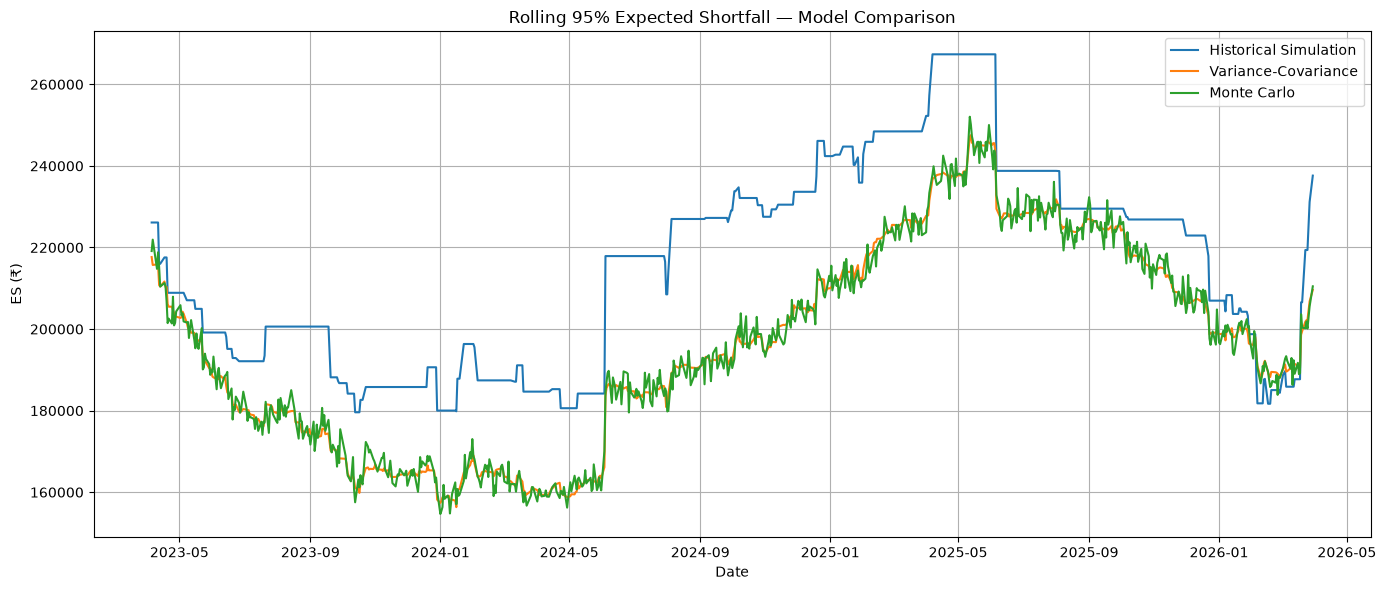

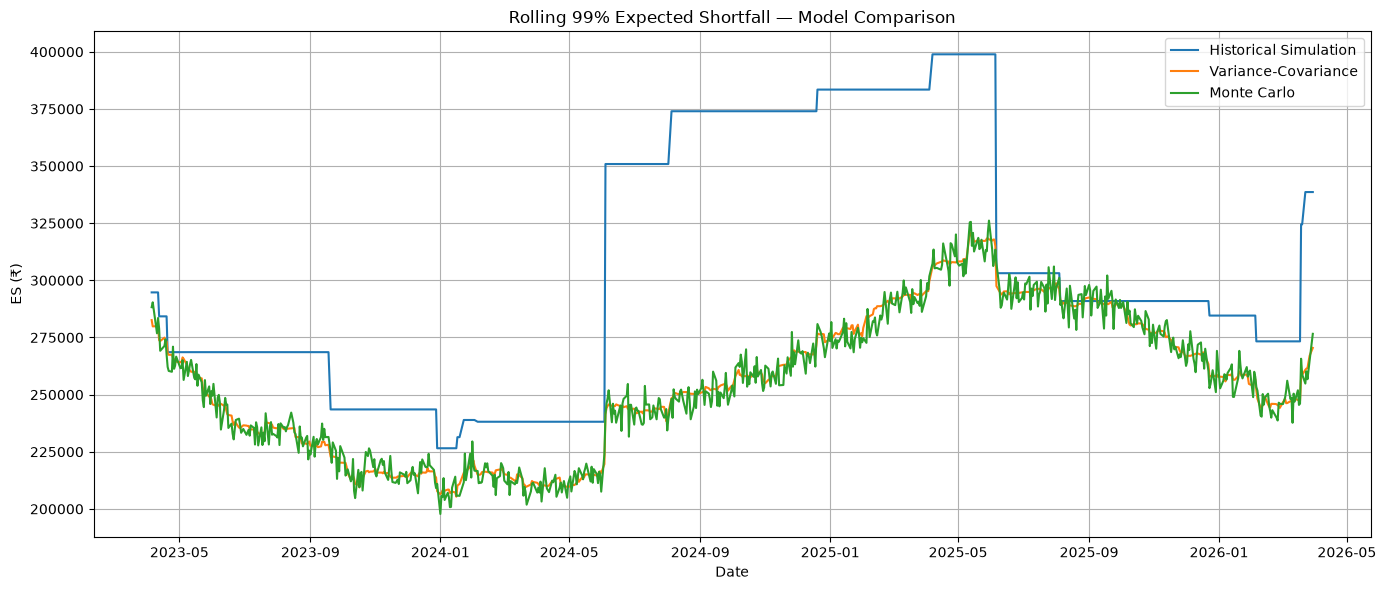

In [49]:
#95% ES — all three models
plt.figure(figsize=(14, 6))

plt.plot(
    rolling_historical_95.index,
    rolling_historical_95["ES"],
    label="Historical Simulation"
)

plt.plot(
    rolling_vc_95.index,
    rolling_vc_95["ES"],
    label="Variance-Covariance"
)

plt.plot(
    rolling_mc_95.index,
    rolling_mc_95["ES"],
    label="Monte Carlo"
)

plt.title("Rolling 95% Expected Shortfall — Model Comparison")
plt.xlabel("Date")
plt.ylabel("ES (₹)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

#99% ES — all three models
plt.figure(figsize=(14, 6))

plt.plot(
    rolling_historical_99.index,
    rolling_historical_99["ES"],
    label="Historical Simulation"
)

plt.plot(
    rolling_vc_99.index,
    rolling_vc_99["ES"],
    label="Variance-Covariance"
)

plt.plot(
    rolling_mc_99.index,
    rolling_mc_99["ES"],
    label="Monte Carlo"
)

plt.title("Rolling 99% Expected Shortfall — Model Comparison")
plt.xlabel("Date")
plt.ylabel("ES (₹)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()